# Análise dos dados IFData

Este notebook apresenta uma análise exploratória e estatística dos dados disponibilizados pela IFData. O objetivo é utilizar ferramentas da linguagem Python para realizar o carregamento, tratamento, exploração e análise das informações presentes na base de dados.

Ao longo do trabalho, serão aplicadas diferentes técnicas de manipulação e visualização de dados, buscando compreender as características da base e extrair informações relevantes a partir das variáveis disponíveis.

A análise será desenvolvida de forma estruturada, passando pelas seguintes etapas:

1. Importação das bibliotecas e configuração do ambiente;
2. Carregamento e organização dos dados;
3. Exploração inicial da base;
4. Tratamento e preparação dos dados;
5. Análise e visualização das informações;
6. Interpretação dos resultados.

**Base de dados:** If.data - Setembro/2025 - Valores em R$ mil
**Fonte:** https://www3.bcb.gov.br/ifdata 



## Parte 1 - Imports e Configuração de ambiente
O script abaixo configura o ambiente para que os frameworks sejam importados e, posteriormente, utilizados nas análises.


In [42]:
# ==========================================
# IMPORTS E CONFIGURAÇÃO DE AMBIENTE
# ==========================================

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings

#### Importação da base de dados - IFData_-_09_2025

Os códigos abaixo executam 3 tarefas com relação a base de dados

**1. Importação da base e contagem do número de linhas e colunas, assim como o nome de cada coluna**

**2. Visualização dos 10 primeiros registros do banco de dados**

**3. Informações gerais sobre o banco de dados**

In [22]:
# Carregamento da base de dados
ARQUIVO_DADOS = r"C:/Users/Usuário/Desktop/kaggle_ds/mini_projetos_2/IFData_-_09_2025.csv"

df_raw = pd.read_csv(
    ARQUIVO_DADOS,
    sep=";",
    encoding="utf-8-sig"
)

print(f"Linhas: {df_raw.shape[0]:,}")
print(f"Colunas: {df_raw.shape[1]}")

print("\nColunas disponíveis:")

for col in df_raw.columns:
    print(f"  - {col}")

Linhas: 1,499
Colunas: 19

Colunas disponíveis:
  - Instituição
  - Código
  - TCB
  - SR
  - TD
  - TC
  - Cidade
  - UF
  - Data
  - Ativo Total
  - Carteira de Crédito
  - Títulos e Valores Mobiliários
  - Passivo Exigível
  - Captações
  - Patrimônio Líquido
  - Lucro Líquido
  - Número de Agências
  - Número de Postos de Atendimento
  - Unnamed: 18


In [23]:
# Visualização ds primeiras linhas

df_raw.head(10)

,Instituição,Código,TCB,SR,TD,TC,Cidade,UF,Data,Ativo Total,Carteira de Crédito,Títulos e Valores Mobiliários,Passivo Exigível,Captações,Patrimônio Líquido,Lucro Líquido,Número de Agências,Número de Postos de Atendimento,Unnamed: 18
0,ITAU,10069.0,b1,S1,C,2.0,SAO PAULO,SP,09/2025,2.689.456.820,1.119.067.920,659.840.783,2.474.135.126,2.105.016.675,215.321.694,11.961.715,1.727,1.285,NaN
1,BB,49906.0,b1,S1,C,1.0,BRASILIA,DF,09/2025,2.538.606.264,1.103.570.994,659.102.445,2.359.524.419,2.015.972.025,179.081.845,3.100.155,3.995,398,NaN
2,CAIXA ECONÔMICA FEDERAL,51626.0,b1,S1,C,1.0,BRASILIA,DF,09/2025,2.193.995.134,1.258.965.203,433.520.123,2.081.316.463,1.911.742.569,112.678.670,3.510.204,3.247,1.023,NaN
3,BRADESCO,10045.0,b1,S1,C,2.0,OSASCO,SP,09/2025,1.826.149.502,842.463.316,299.048.054,1.646.311.796,1.430.201.829,179.837.706,6.384.369,2.157,808,NaN
4,SANTANDER,30379.0,b1,S1,C,3.0,SAO PAULO,SP,09/2025,1.276.426.350,528.719.260,271.940.975,1.181.383.526,984.251.575,95.042.824,4.106.122,2.136,1.789,NaN
5,BANCO NACIONAL DE DESENVOLVIMENTO ECONOMICO E ...,33657248.0,b4,S2,C,1.0,RIO DE JANEIRO,RJ,09/2025,905.220.074,337.101.530,163.600.304,736.690.922,596.672.518,168.529.152,3.897.466,5,0,NaN
6,BTG PACTUAL,49944.0,b1,S1,C,2.0,RIO DE JANEIRO,RJ,09/2025,665.445.894,168.426.944,205.485.096,597.330.797,460.048.347,68.115.098,4.337.377,66,0,NaN
7,XP,52120.0,b1,S2,C,2.0,RIO DE JANEIRO,RJ,09/2025,307.101.659,33.329.722,109.000.669,294.990.308,219.008.553,12.111.351,205.279,11,0,NaN
8,SAFRA,10083.0,b1,S2,C,2.0,SAO PAULO,SP,09/2025,271.094.929,132.708.479,69.307.857,252.005.262,207.723.576,19.089.667,1.128.996,188,3,NaN
9,NUBANK,52058.0,n1,S2,C,3.0,SAO PAULO,SP,09/2025,219.449.385,61.661.647,65.169.820,207.181.651,186.790.022,12.267.733,2.198.336,4,0,NaN


In [24]:
# Informações sobre tipos e nulos
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Instituição                      1499 non-null   str    
 1   Código                           1459 non-null   float64
 2   TCB                              1459 non-null   str    
 3   SR                               1335 non-null   str    
 4   TD                               1458 non-null   str    
 5   TC                               1459 non-null   float64
 6   Cidade                           1459 non-null   str    
 7   UF                               1459 non-null   str    
 8   Data                             1459 non-null   str    
 9   Ativo Total                      1495 non-null   str    
 10  Carteira de Crédito              1495 non-null   str    
 11  Títulos e Valores Mobiliários    1495 non-null   str    
 12  Passivo Exigível               

## Parte 2 - Limpeza e Preparação dos Dados

**1. Criação de uma cópia da base:**  
A partir da base original `df_raw`, foi criada uma cópia denominada `df`, que será utilizada nas etapas de tratamento e manipulação dos dados, preservando a estrutura original da base.

**2. Filtragem e padronização dos dados:**  
Foram removidos registros sem informações necessárias para a análise e valores não informados. Em seguida, as variáveis financeiras, inicialmente armazenadas como texto, foram convertidas para valores numéricos. As variáveis relacionadas ao número de agências e postos de atendimento também foram convertidas para o formato adequado. Por fim, foram removidas duplicidades e reorganizado o índice da base.

**3. Criação de variáveis derivadas:**  
A partir das variáveis disponíveis, foram criadas novas informações para a análise, incluindo o ROE, o índice entre carteira de crédito e ativo total, a classificação das instituições entre digitais e tradicionais e a identificação do tipo de controle da instituição.


In [13]:
# Trabalhar em uma cópia
df = df_raw.copy()

# Remover linhas sem TCB (totalizadoras no final do arquivo)
df = df[df['TCB'].notna() & (df['TCB'] != '')]

# Remover linhas com Ativo Total = NI ou vazio
df = df[~df['Ativo Total'].isin(['NI', '', None])]
df = df[df['Ativo Total'].notna()]

print(f'Após filtros: {len(df):,} registros')

Após filtros: 1,419 registros


In [15]:
# Converter colunas financeiras para número
colunas_financeiras = [
    'Ativo Total', 'Carteira de Crédito', 'Títulos e Valores Mobiliários',
    'Passivo Exigível', 'Captações', 'Patrimônio Líquido', 'Lucro Líquido'
]

for col in colunas_financeiras:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('.', '', regex=False)
            .str.replace(',', '.', regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Converter agências e postos
for col in ['Número de Agências', 'Número de Postos de Atendimento']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Remover duplicatas
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print(f'Base limpa: {len(df):,} registros')
print(f'Colunas numéricas OK: {df[colunas_financeiras].dtypes.tolist()}')

Base limpa: 1,419 registros
Colunas numéricas OK: [dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64')]


In [16]:
# Criar colunas calculadas
df['ROE'] = df['Lucro Líquido'] / df['Patrimônio Líquido'].replace(0, np.nan)
df['Indice_Credito_Ativo'] = df['Carteira de Crédito'] / df['Ativo Total'].replace(0, np.nan)
df['Digital'] = (df['Número de Agências'] == 0).map({True: 'Digital', False: 'Tradicional'})

# Decodificar tipo de controle
tc_map = {'1': 'Público', '2': 'Privado Nacional', '3': 'Privado Estrangeiro'}
df['Tipo_Controle'] = df['TC'].astype(str).map(tc_map)

print('Colunas calculadas criadas:')
print('  - ROE (Retorno sobre Patrimônio)')
print('  - Indice_Credito_Ativo')
print('  - Digital (Digital/Tradicional)')
print('  - Tipo_Controle (legível)')

Colunas calculadas criadas:
  - ROE (Retorno sobre Patrimônio)
  - Indice_Credito_Ativo
  - Digital (Digital/Tradicional)
  - Tipo_Controle (legível)


## EXERCÍCIO 1 — Verificação da qualidade

Responda as perguntas abaixo usando Pandas:
1. Quantos registros têm ROE nulo?
2. Qual a porcentagem de registros nulos em `Lucro Líquido`?
3. Quais são os valores únicos de `SR` (segmento) na base limpa?

#### Soluções: Exercício 1

Após o processo de limpeza e preparação, é importante verificar se a base resultante apresenta informações ausentes que possam afetar as análises posteriores. Para isso, serão avaliadas a presença de valores nulos na variável `ROE`, a proporção de registros sem informação em `Lucro Líquido` e a composição da variável `SR`, identificando os segmentos presentes na base.

In [17]:
# Verificação de valores nulos em ROE
roe_nulos = df['ROE'].isna().sum()

print(f"Registros com ROE nulo: {roe_nulos:,}")


# Porcentagem de valores nulos em Lucro Líquido
lucro_nulos = df['Lucro Líquido'].isna().mean() * 100

print(f"Registros com Lucro Líquido nulo: {lucro_nulos:.2f}%")


# Valores únicos da variável SR
segmentos = df['SR'].dropna().unique()

print("\nSegmentos presentes na base:")
for segmento in segmentos:
    print(f" - {segmento}")

Registros com ROE nulo: 0
Registros com Lucro Líquido nulo: 0.00%

Segmentos presentes na base:
 - S1
 - S2
 - S3
 - S4
 - S5


## Parte 3 - Análise Exploratória de Dados

Com a base já limpa e preparada, neste capítulo é iniciado a análise exploratória dos dados. O objetivo desta etapa é obter uma visão geral das características da base, observando tanto o comportamento das principais variáveis numéricas quanto a distribuição das instituições segundo diferentes classificações.

 **1. Estatísticas descritivas**

Inicialmente, são analisadas algumas das principais variáveis financeiras e o indicador ROE. As estatísticas descritivas permitem observar medidas como quantidade de registros, média, desvio-padrão, valores mínimo e máximo e quartis, fornecendo uma primeira visão sobre a escala e a variabilidade dos dados.

**2. Distribuição das instituições**

Em seguida, são examinadas as distribuições das instituições segundo o tipo de controle, o segmento (`SR`) e a classificação entre instituições digitais e tradicionais. Essa etapa permite compreender como a base está estruturada e identificar quais categorias possuem maior ou menor representação.

**3. Comparação por segmento**

Para aprofundar a exploração, são calculadas estatísticas agregadas por segmento. São considerados o número de instituições, o volume total e médio de ativos, a carteira de crédito, o lucro líquido e o ROE médio. Também é calculada a participação de cada segmento no total de ativos da base, permitindo comparar não apenas a quantidade de instituições, mas também sua representatividade econômica.

**4. Relações entre variáveis**

Por fim, é analisada a correlação entre algumas das principais variáveis financeiras e o número de agências. A matriz de correlação permite observar a intensidade e a direção das relações lineares entre essas variáveis, servindo como uma primeira indicação de possíveis associações que podem ser investigadas posteriormente.

In [18]:
# Estatísticas descritivas das variáveis numéricas principais
cols_analise = ['Ativo Total', 'Carteira de Crédito', 'Patrimônio Líquido', 'Lucro Líquido', 'ROE']
df[cols_analise].describe().round(2)

,Ativo Total,Carteira de Crédito,Patrimônio Líquido,Lucro Líquido,ROE
count,1.419000e+03,1.419000e+03,1.419000e+03,1419.00,1419.00
mean,1.264899e+07,5.279066e+06,1.166588e+06,42384.61,-0.02
std,1.329475e+08,6.066277e+07,1.090986e+07,439282.84,1.11
min,3.750000e+02,0.000000e+00,-4.147200e+04,-252606.00,-36.20
25%,1.759250e+04,1.845000e+02,8.747500e+03,10.00,0.00
50%,2.576570e+05,4.992100e+04,4.638500e+04,632.00,0.02
75%,1.468441e+06,5.570000e+05,2.169150e+05,5722.50,0.05
max,2.689457e+09,1.258965e+09,2.153217e+08,11961715.00,4.12


In [25]:
# Distribuição por tipo de controle
print('*** Distribuição por Tipo de Controle ***')
print(df['Tipo_Controle'].value_counts())
print()

# Distribuição por segmento
print('*** Distribuição por Segmento (SR) ***')
print(df['SR'].value_counts().sort_index())
print()

# Bancos digitais vs tradicionais
print('*** Digital vs Tradicional ***')
print(df['Digital'].value_counts())

*** Distribuição por Tipo de Controle ***
Series([], Name: count, dtype: int64)

*** Distribuição por Segmento (SR) ***
SR
S1     11
S2     14
S3     71
S4    382
S5    828
Name: count, dtype: int64

*** Digital vs Tradicional ***
Digital
Digital        767
Tradicional    652
Name: count, dtype: int64


In [20]:
# Resumo por segmento — o coração da EDA
resumo_segmento = df.groupby('SR').agg(
    qtd=('Instituição', 'count'),
    ativo_soma=('Ativo Total', 'sum'),
    ativo_medio=('Ativo Total', 'mean'),
    credito_soma=('Carteira de Crédito', 'sum'),
    roe_medio=('ROE', 'mean'),
    lucro_soma=('Lucro Líquido', 'sum')
).round(2)

resumo_segmento['pct_ativo'] = (resumo_segmento['ativo_soma'] / resumo_segmento['ativo_soma'].sum() * 100).round(1)

print(resumo_segmento.to_string())

    qtd   ativo_soma   ativo_medio  credito_soma  roe_medio  lucro_soma  pct_ativo
SR                                                                                
S1   11  11420629420  1.038239e+09    5037217362      -0.22    34368024       64.2
S2   14   2811793783  2.008424e+08     891168607       0.06    12936601       15.8
S3   71   2195713757  3.092555e+07     922615546       0.03     6751033       12.3
S4  382    901420249  2.359739e+06     389222314      -0.07     3434666        5.1
S5  828    463986554  5.603702e+05     248358598       0.01     1933594        2.6


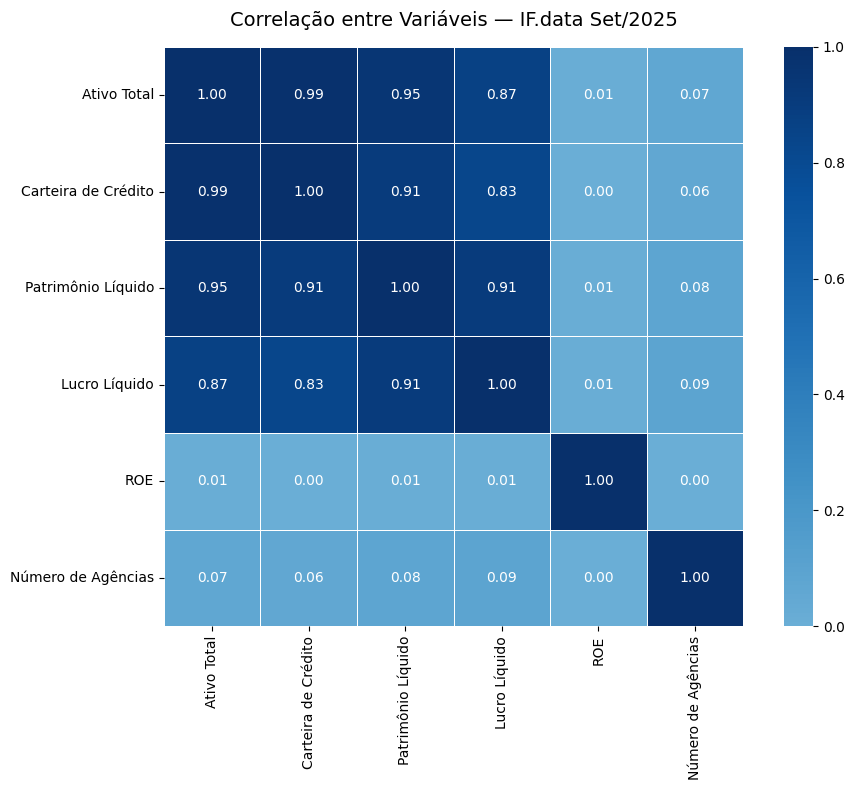

✓ Gráfico salvo: correlacao_ifdata.png


In [21]:
# Matriz de correlação
plt.rcParams['font.family'] = 'DejaVu Sans'

corr_cols = ['Ativo Total', 'Carteira de Crédito', 'Patrimônio Líquido',
             'Lucro Líquido', 'ROE', 'Número de Agências']
corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlação entre Variáveis — IF.data Set/2025', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlacao_ifdata.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico salvo: correlacao_ifdata.png')

## EXERCÍCIO 2 — Análise exploratória

1. Qual é a mediana do `Ativo Total`? Compare com a média. O que a diferença indica?
2. Quantas instituições têm ROE acima de 15% (Excelente)?
3. Qual a correlação entre `Número de Agências` e `Ativo Total`? O que isso significa?
4. Crie um resumo por `Tipo_Controle` com soma de ativo e ROE médio.

## Soluções: Exercício 2

A análise inicial da distribuição dos dados permite aprofundar a compreensão sobre o perfil das instituições presentes na base. Nesta etapa, serão comparadas medidas de posição da variável `Ativo Total`, identificadas instituições com valores elevados de ROE e investigada a relação entre o número de agências e o tamanho dos ativos.

Também será realizada uma comparação entre os diferentes tipos de controle, considerando o volume total de ativos e o ROE médio de cada grupo. Essas análises permitem observar diferenças relevantes entre as instituições e levantar possíveis relações entre suas características financeiras e estruturais.

In [26]:
media_ativo = df['Ativo Total'].mean()
mediana_ativo = df['Ativo Total'].median()

print(f"Média do Ativo Total: R$ {media_ativo:,.2f}")
print(f"Mediana do Ativo Total: R$ {mediana_ativo:,.2f}")

Média do Ativo Total: R$ 12,648,993.82
Mediana do Ativo Total: R$ 257,657.00


### Interpretação:

A mediana do `Ativo Total` é consideravelmente inferior à média. Essa diferença indica uma distribuição assimétrica, na qual algumas instituições com valores muito elevados de ativos elevam a média. 
A mediana representa melhor o perfil da instituição típica da base.

In [27]:
instituicoes_roe = (df['ROE'] > 0.15).sum()

print(f"Instituições com ROE acima de 15%: {instituicoes_roe}")

Instituições com ROE acima de 15%: 66


### Interpretação:

Foram identificadas 66 instituições com ROE superior a 15%. Esse grupo representa as instituições classificadas como de desempenho excelente segundo o critério estabelecido para a análise.

In [31]:
correlacao = df['Número de Agências'].corr(df['Ativo Total'])

print(f"Correlação entre Número de Agências e Ativo Total: {correlacao:.2f}")

Correlação entre Número de Agências e Ativo Total: 0.07


### Interpretação:

A correlação entre o número de agências e o `Ativo Total` foi de aproximadamente 0,07, indicando uma associação linear muito fraca entre as variáveis. Portanto, na base analisada, o número de agências apresenta pouca relação linear com o volume de ativos das instituições.

In [30]:
tc_map = {
    1: 'Público',
    2: 'Privado Nacional',
    3: 'Privado Estrangeiro'
}

df['Tipo_Controle'] = df['TC'].map(tc_map)

resumo_controle = df.groupby('Tipo_Controle').agg(
    ativo_soma=('Ativo Total', 'sum'),
    roe_medio=('ROE', 'mean')
).round(2)

print(resumo_controle)

                     ativo_soma  roe_medio
Tipo_Controle                             
Privado Estrangeiro  3022481106       0.02
Privado Nacional     8776628286      -0.03
Público              6149812836       0.01


### Interpretação:

O resumo permite comparar os diferentes tipos de controle quanto ao volume total de ativos e ao ROE médio. Dessa forma, é possível observar diferenças tanto na dimensão econômica dos grupos quanto em seu desempenho médio sobre o patrimônio líquido.

## Parte 4 - Visualização com Matplotlib e Seaborn

Após a exploração das características numéricas e categóricas da base, serão utilizadas técnicas de visualização para facilitar a interpretação dos principais resultados.

Inicialmente, será apresentado um ranking das 10 instituições com maior `Ativo Total`, permitindo identificar as instituições de maior porte na base. Em seguida, será analisada a participação do ativo total segundo o `Tipo_Controle`, possibilitando comparar a representatividade dos diferentes grupos.

Por fim, será apresentada a distribuição do `ROE` médio por segmento (`SR`), incluindo referências de 8% e 15% para facilitar a avaliação do desempenho entre os segmentos.

Os gráficos serão construídos utilizando `Matplotlib` e `Seaborn`, com ajustes de títulos, eixos, rótulos e formatação dos valores para tornar as informações mais claras. Os resultados também serão salvos em arquivos de imagem para utilização posterior.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_28092\1295786566.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(


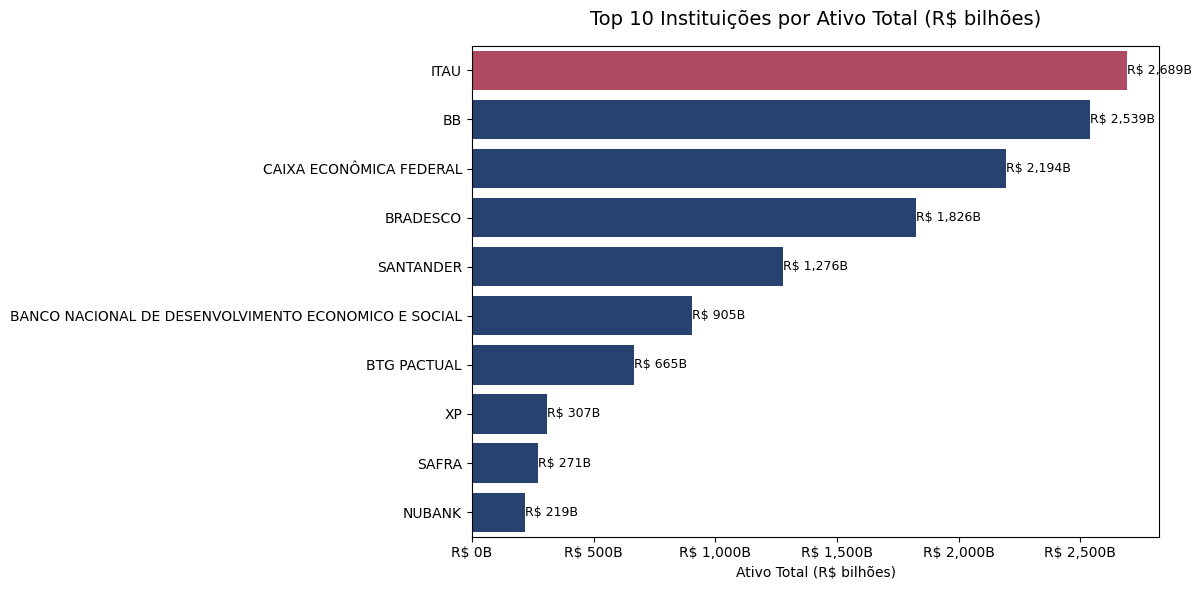

✓ top10_ativo.png


In [34]:
# Constantes
# ARQUIVO_DADOS = 'IFData_-_09_2025.csv'
COR_PRINCIPAL = '#1B3F7A'
COR_DESTAQUE  = '#C0395A'

# Gráfico 1: Top 10 por Ativo Total
top10 = df.nlargest(10, 'Ativo Total')[['Instituição', 'SR', 'Ativo Total', 'ROE']].copy()
top10['Ativo_Bi'] = top10['Ativo Total'] / 1_000_000  # converter para R$ bilhões

fig, ax = plt.subplots(figsize=(12, 6))
barras = sns.barplot(
    data=top10, y='Instituição', x='Ativo_Bi',
    palette=[COR_DESTAQUE if i == 0 else COR_PRINCIPAL for i in range(len(top10))],
    ax=ax
)
ax.set_title('Top 10 Instituições por Ativo Total (R$ bilhões)', fontsize=14, pad=15)
ax.set_xlabel('Ativo Total (R$ bilhões)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}B'))
for bar in ax.patches:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'R$ {bar.get_width():,.0f}B', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top10_ativo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ top10_ativo.png')



In [ ]:
print(df.columns.tolist())
print(df['Tipo_Controle'].value_counts())

In [ ]:
print(df[['TCB', 'SR', 'TD', 'TC']].value_counts().head(20))

In [ ]:
mapa_controle = {
    1: 'Privado Nacional',
    2: 'Privado Nacional',
    3: 'Estrangeiro'
}

# Código do IF.data: 1=Público Federal, 2=Privado Nacional, 3=Estrangeiro
mapa_controle = {
    1: 'Público Federal',
    2: 'Privado Nacional',
    3: 'Estrangeiro'
}

df['Tipo_Controle'] = df['TC'].map(mapa_controle)
print(df['Tipo_Controle'].value_counts())

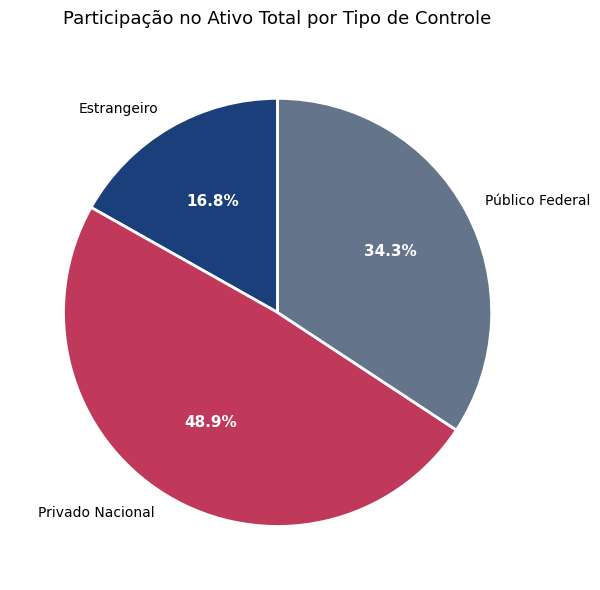

✓ ativo_controle.png


In [38]:
# Gráfico 2: Distribuição de ativo por tipo de controle
ativo_controle = df.groupby('Tipo_Controle')['Ativo Total'].sum().reset_index()
ativo_controle['pct'] = ativo_controle['Ativo Total'] / ativo_controle['Ativo Total'].sum() * 100

fig, ax = plt.subplots(figsize=(8, 6))
cores = [COR_PRINCIPAL, COR_DESTAQUE, '#64748B']
wedges, texts, autotexts = ax.pie(
    ativo_controle['Ativo Total'],
    labels=ativo_controle['Tipo_Controle'],
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_color('white')
    text.set_fontweight('bold')
ax.set_title('Participação no Ativo Total por Tipo de Controle', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('ativo_controle.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ ativo_controle.png')

C:\Users\Usuário\AppData\Local\Temp\ipykernel_28092\1910411069.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roe_seg, x='SR', y='ROE', palette=cores_roe, ax=ax)


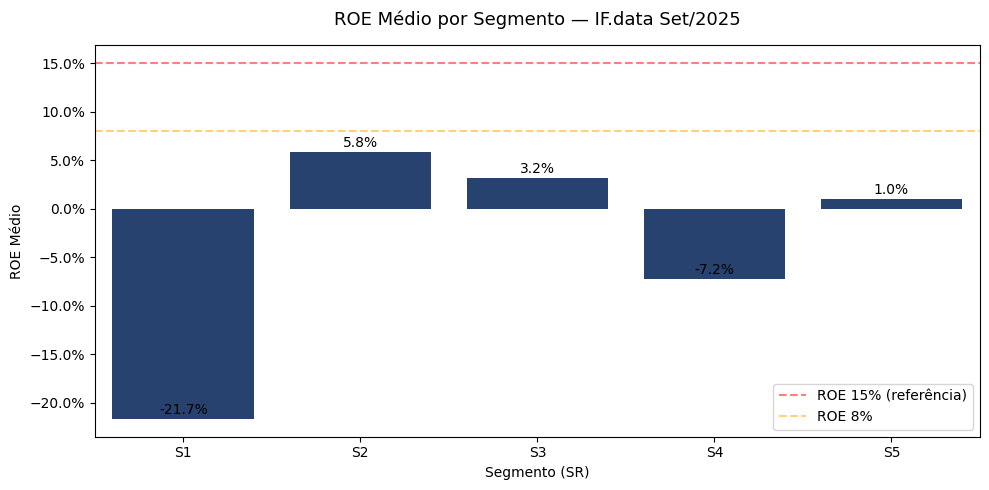

✓ roe_segmento.png


In [39]:
# Gráfico 3: ROE por segmento
roe_seg = df.groupby('SR')['ROE'].mean().reset_index().sort_values('SR')
roe_seg = roe_seg[roe_seg['SR'].isin(['S1','S2','S3','S4','S5'])]

fig, ax = plt.subplots(figsize=(10, 5))
cores_roe = [COR_DESTAQUE if r > 0.15 else COR_PRINCIPAL for r in roe_seg['ROE']]
sns.barplot(data=roe_seg, x='SR', y='ROE', palette=cores_roe, ax=ax)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.axhline(0.15, color='red', linestyle='--', alpha=0.5, label='ROE 15% (referência)')
ax.axhline(0.08, color='orange', linestyle='--', alpha=0.5, label='ROE 8%')
ax.set_title('ROE Médio por Segmento — IF.data Set/2025', fontsize=13, pad=15)
ax.set_xlabel('Segmento (SR)')
ax.set_ylabel('ROE Médio')
ax.legend()

# Rótulos nas barras
for bar in ax.patches:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f'{h:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('roe_segmento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ roe_segmento.png')

## Parte 5 — Exportação dos Resultados

Todos os resultados vão para um Excel com múltiplas abas e os gráficos em PNG.  
Este é o entregável final do projeto.

In [40]:
# Preparar tabelas para exportação
top10_export = df.nlargest(10, 'Ativo Total')[[
    'Instituição', 'SR', 'Tipo_Controle', 'UF',
    'Ativo Total', 'Carteira de Crédito', 'Patrimônio Líquido',
    'Lucro Líquido', 'ROE', 'Número de Agências', 'Digital'
]].copy()

top10_export['ROE'] = top10_export['ROE'].apply(lambda x: f'{x:.1%}' if pd.notna(x) else 'N/A')

# Classificar ROE
def classificar_roe(roe_str):
    if roe_str == 'N/A': return 'N/A'
    roe = float(roe_str.strip('%')) / 100
    if roe > 0.15: return 'Excelente'
    if roe > 0.08: return 'Bom'
    if roe > 0: return 'Fraco'
    return 'Prejuízo'

top10_export['Classificação ROE'] = top10_export['ROE'].apply(classificar_roe)

print('Tabela pronta para exportação:')
print(top10_export[['Instituição', 'SR', 'ROE', 'Classificação ROE']].to_string())

Tabela pronta para exportação:
                                            Instituição  SR    ROE Classificação ROE
0                                                  ITAU  S1   5.6%             Fraco
1                                                    BB  S1   1.7%             Fraco
2                               CAIXA ECONÔMICA FEDERAL  S1   3.1%             Fraco
3                                              BRADESCO  S1   3.6%             Fraco
4                                             SANTANDER  S1   4.3%             Fraco
5  BANCO NACIONAL DE DESENVOLVIMENTO ECONOMICO E SOCIAL  S2   2.3%             Fraco
6                                           BTG PACTUAL  S1   6.4%             Fraco
7                                                    XP  S2   1.7%             Fraco
8                                                 SAFRA  S2   5.9%             Fraco
9                                                NUBANK  S2  17.9%         Excelente


In [ ]:
# Exportar para Excel com múltiplas abas
with pd.ExcelWriter('M6_Analise_IFdata.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Base_Limpa', index=False)
    top10_export.to_excel(writer, sheet_name='Top10_Ativo', index=False)
    resumo_segmento.to_excel(writer, sheet_name='Resumo_Segmento')

# Exportar base limpa em CSV
df.to_csv('ifdata_limpo.csv', index=False, encoding='utf-8-sig')

print('✓ Arquivos exportados:')
print('  - M6_Analise_IFdata.xlsx (3 abas)')
print('  - ifdata_limpo.csv')
print('  - top10_ativo.png')
print('  - ativo_controle.png')
print('  - roe_segmento.png')
print('  - correlacao_ifdata.png')

## Parte 6 - Conclusão


A análise exploratória da base IFData permitiu identificar algumas características relevantes das instituições analisadas. Inicialmente, o processo de limpeza e preparação foi fundamental para transformar as informações financeiras, originalmente armazenadas em formato textual, em variáveis adequadas para análise, além de tratar valores ausentes e registros que não representavam instituições individuais.

Entre os principais resultados, destaca-se a diferença significativa entre a média e a mediana do `Ativo Total`. A média, superior à mediana, evidencia uma distribuição assimétrica, influenciada pela presença de instituições com volumes de ativos muito elevados. Dessa forma, a mediana se mostra uma medida mais representativa do perfil da instituição típica da base.

Em relação ao desempenho, foram identificadas 66 instituições com ROE superior a 15%, segundo o critério utilizado na análise. Esse resultado demonstra a existência de um grupo de instituições com elevado retorno sobre o patrimônio líquido.

Por outro lado, a correlação de aproximadamente 0,07 entre o `Número de Agências` e o `Ativo Total` indica uma associação linear muito fraca entre essas variáveis. Assim, dentro da base analisada, possuir um maior volume de ativos não está necessariamente relacionado a possuir um maior número de agências.
